In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [3]:
# ==================== The fine graph ====================
edges = [
    (0,1),(1,2),(2,3),(0,2),(3,4),(4,5),(5,6),(6,7),(4,6),(7,8),
    (8,9),(9,10),(10,11),(11,12),(9,11),(8,10),(12,13),(13,14),(14,15),(15,16),(13,15),
    (16,17),(17,18),(18,19),(19,20),(17,19),(20,21),(21,22),(22,23),(20,22),
]
G_nx = nx.Graph()
G_nx.add_edges_from(edges)
n_vertices = 24
gamma_in = [0, 1]
gamma_out = [22, 23]

print(f"n_vertices: {n_vertices}, n_edges: {len(edges)}")
print(f"boundary fraction: {(len(gamma_in)+len(gamma_out))/n_vertices:.4f}")

n_vertices: 24, n_edges: 30
boundary fraction: 0.1667


In [5]:
def build_capped_aggregation(G_nx, gamma_in, gamma_out, max_size=4):
    gamma_in_set = set(gamma_in)
    gamma_out_set = set(gamma_out)
    boundary_set = gamma_in_set | gamma_out_set
    aggregate_of = {}
    agg_sizes = {}
    agg_has_gamma_in = {}
    agg_has_gamma_out = {}
    next_agg_id = 0

    def forbidden_pair(a, b):
        return (a in gamma_in_set and b in gamma_out_set) or (a in gamma_out_set and b in gamma_in_set)

    # Step 1: boundary vertices first, forced to pair with an interior neighbor
    boundary_nodes_by_degree = sorted(boundary_set, key=lambda v: G_nx.degree(v))
    for v in boundary_nodes_by_degree:
        if v in aggregate_of:
            continue
        partner = None
        for neighbor in G_nx.neighbors(v):
            if neighbor not in aggregate_of and neighbor not in boundary_set:
                partner = neighbor
                break
        if partner is not None:
            aggregate_of[v] = next_agg_id
            aggregate_of[partner] = next_agg_id
            agg_sizes[next_agg_id] = 2
            agg_has_gamma_in[next_agg_id] = v in gamma_in_set
            agg_has_gamma_out[next_agg_id] = v in gamma_out_set
            next_agg_id += 1

    # Step 2: everyone else
    remaining_by_degree = sorted(
        [v for v in G_nx.nodes() if v not in aggregate_of],
        key=lambda v: G_nx.degree(v)
    )
    for v in remaining_by_degree:
        if v in aggregate_of:
            continue
        partner = None
        for neighbor in G_nx.neighbors(v):
            if neighbor not in aggregate_of and not forbidden_pair(v, neighbor):
                partner = neighbor
                break
        if partner is not None:
            aggregate_of[v] = next_agg_id
            aggregate_of[partner] = next_agg_id
            agg_sizes[next_agg_id] = 2
            agg_has_gamma_in[next_agg_id] = (v in gamma_in_set) or (partner in gamma_in_set)
            agg_has_gamma_out[next_agg_id] = (v in gamma_out_set) or (partner in gamma_out_set)
            next_agg_id += 1
        else:
            joined = False
            for neighbor in G_nx.neighbors(v):
                if neighbor in aggregate_of and not forbidden_pair(v, neighbor):
                    agg_id = aggregate_of[neighbor]
                    v_is_in = v in gamma_in_set
                    v_is_out = v in gamma_out_set
                    if (v_is_in and agg_has_gamma_out.get(agg_id, False)) or \
                       (v_is_out and agg_has_gamma_in.get(agg_id, False)):
                        continue
                    if agg_sizes[agg_id] < max_size:
                        aggregate_of[v] = agg_id
                        agg_sizes[agg_id] += 1
                        agg_has_gamma_in[agg_id] = agg_has_gamma_in.get(agg_id, False) or v_is_in
                        agg_has_gamma_out[agg_id] = agg_has_gamma_out.get(agg_id, False) or v_is_out
                        joined = True
                        break
            if not joined:
                aggregate_of[v] = next_agg_id
                agg_sizes[next_agg_id] = 1
                agg_has_gamma_in[next_agg_id] = v in gamma_in_set
                agg_has_gamma_out[next_agg_id] = v in gamma_out_set
                next_agg_id += 1

    unique_ids = sorted(set(aggregate_of.values()))
    relabel = {old: new for new, old in enumerate(unique_ids)}
    aggregate_of = {v: relabel[a] for v, a in aggregate_of.items()}
    return aggregate_of, len(unique_ids)


aggregate_of, n_coarse = build_capped_aggregation(G_nx, gamma_in, gamma_out, max_size=4)

In [7]:
groups = {}
for v, a in aggregate_of.items():
    groups.setdefault(a, []).append(v)
print(f"\nn_coarse: {n_coarse}")
for a, members in sorted(groups.items()):
    print(f"  Aggregate {a}: {sorted(members)}")

gamma_in_coarse = sorted(set(aggregate_of[v] for v in gamma_in))
gamma_out_coarse = sorted(set(aggregate_of[v] for v in gamma_out))
print(f"gamma_in_coarse: {gamma_in_coarse}, gamma_out_coarse: {gamma_out_coarse}")


n_coarse: 11
  Aggregate 0: [0, 1, 2]
  Aggregate 1: [21, 22, 23]
  Aggregate 2: [3, 4]
  Aggregate 3: [5, 6]
  Aggregate 4: [7, 8]
  Aggregate 5: [11, 12]
  Aggregate 6: [13, 14]
  Aggregate 7: [15, 16]
  Aggregate 8: [17, 18]
  Aggregate 9: [9, 10]
  Aggregate 10: [19, 20]
gamma_in_coarse: [0], gamma_out_coarse: [1]


In [9]:
def build_coarse_graph_edges(edges, aggregate_of):
    coarse_contribs = {}
    for idx, (i, j) in enumerate(edges):
        ai, aj = aggregate_of[i], aggregate_of[j]
        if ai == aj:
            continue
        key = tuple(sorted([ai, aj]))
        coarse_contribs.setdefault(key, []).append(idx)
    coarse_edges = list(coarse_contribs.keys())
    return coarse_edges, coarse_contribs

coarse_edges, coarse_contribs = build_coarse_graph_edges(edges, aggregate_of)
print(f"coarse_edges: {coarse_edges}")

coarse_edges: [(0, 2), (2, 3), (3, 4), (4, 9), (5, 9), (5, 6), (6, 7), (7, 8), (8, 10), (1, 10)]


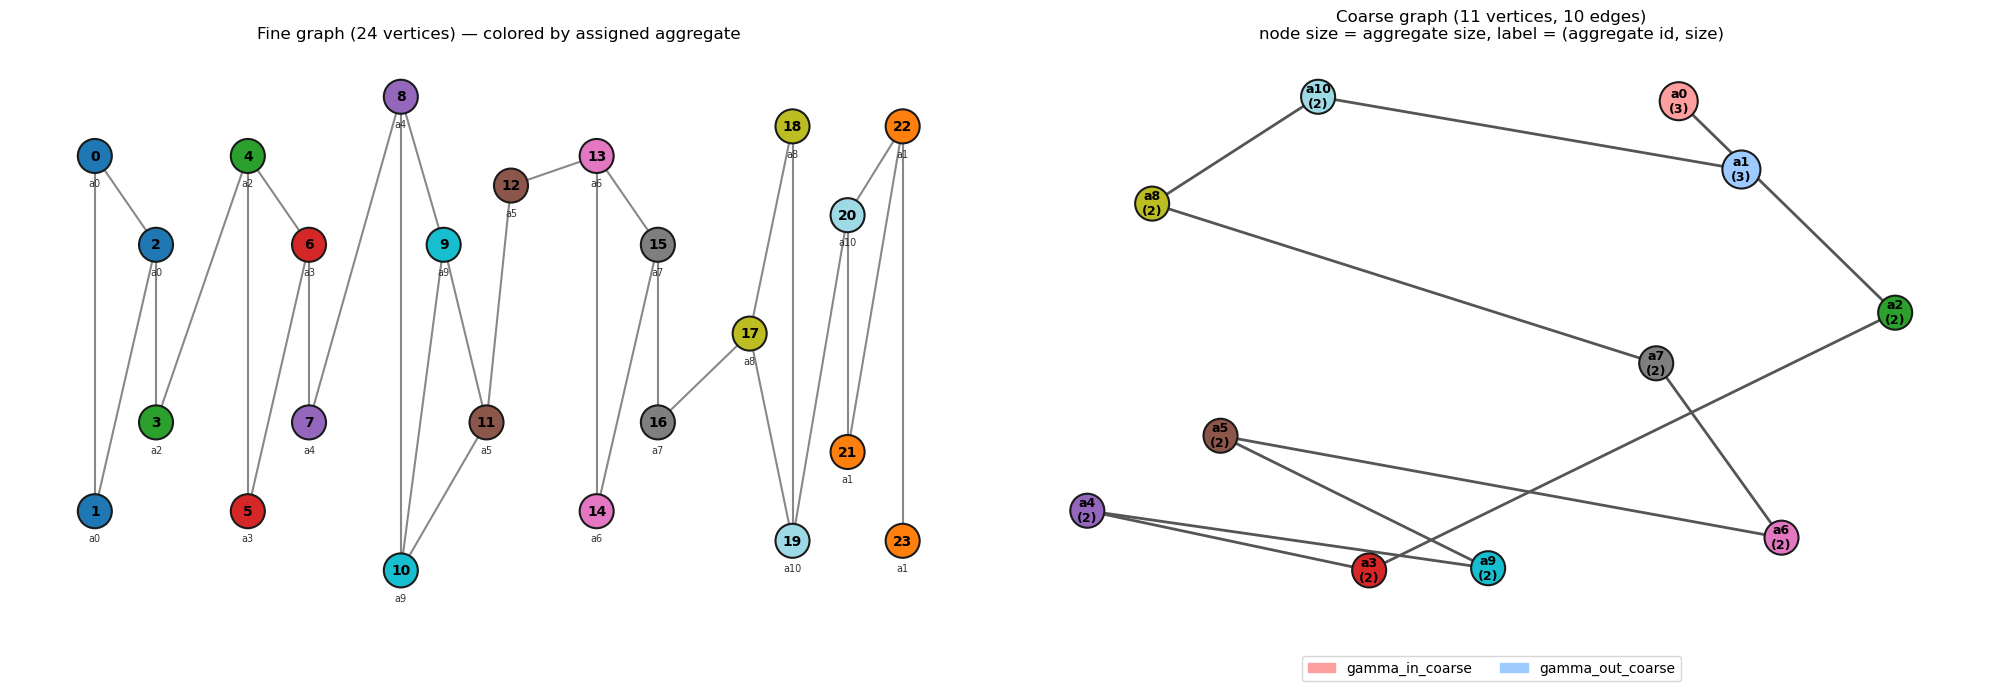

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
pos_fine = {
    0: (-6, 0.6), 1: (-6, -0.6), 2: (-5, 0.3), 3: (-5, -0.3),
    4: (-3.5, 0.6), 5: (-3.5, -0.6), 6: (-2.5, 0.3), 7: (-2.5, -0.3),
    8: (-1, 0.8), 9: (-0.3, 0.3), 10: (-1, -0.8), 11: (0.4, -0.3), 12: (0.8, 0.5),
    13: (2.2, 0.6), 14: (2.2, -0.6), 15: (3.2, 0.3), 16: (3.2, -0.3),
    17: (4.7, 0), 18: (5.4, 0.7), 19: (5.4, -0.7), 20: (6.3, 0.4),
    21: (6.3, -0.4), 22: (7.2, 0.7), 23: (7.2, -0.7),
}
cmap = plt.colormaps.get_cmap('tab20').resampled(n_coarse)
agg_colors_map = {a: cmap(a) for a in range(n_coarse)}
node_colors_fine = [agg_colors_map[aggregate_of[v]] for v in G_nx.nodes()]

ax = axes[0]
nx.draw_networkx_edges(G_nx, pos_fine, ax=ax, width=1.5, edge_color='#888')
nx.draw_networkx_nodes(G_nx, pos_fine, ax=ax, node_size=600, node_color=node_colors_fine,
                        edgecolors='#1a1a1a', linewidths=1.5)
nx.draw_networkx_labels(G_nx, pos_fine, ax=ax, font_size=10, font_weight='bold')
for v, (x, y) in pos_fine.items():
    ax.annotate(f"a{aggregate_of[v]}", (x, y), xytext=(0, -22), textcoords='offset points',
                fontsize=7, ha='center', color='#333')
ax.set_title(f"Fine graph ({n_vertices} vertices) — colored by assigned aggregate")
ax.axis('off')

G_coarse = nx.Graph()
G_coarse.add_nodes_from(range(n_coarse))
G_coarse.add_edges_from(coarse_edges)
pos_coarse = nx.spring_layout(G_coarse, seed=3, k=1.5)

sizes = {a: len(m) for a, m in groups.items()}
node_sizes_coarse = [300 + sizes[a] * 150 for a in G_coarse.nodes()]
gamma_in_coarse_set = set(gamma_in_coarse)
gamma_out_coarse_set = set(gamma_out_coarse)
node_colors_coarse = [
    '#ff9e9e' if a in gamma_in_coarse_set else
    '#9ecbff' if a in gamma_out_coarse_set else
    agg_colors_map[a]
    for a in G_coarse.nodes()
]

ax = axes[1]
nx.draw_networkx_edges(G_coarse, pos_coarse, ax=ax, width=2, edge_color='#555')
nx.draw_networkx_nodes(G_coarse, pos_coarse, ax=ax, node_size=node_sizes_coarse,
                        node_color=node_colors_coarse, edgecolors='#1a1a1a', linewidths=1.5)
labels_coarse = {a: f"a{a}\n({sizes[a]})" for a in G_coarse.nodes()}
nx.draw_networkx_labels(G_coarse, pos_coarse, labels=labels_coarse, ax=ax, font_size=9, font_weight='bold')

legend_patches = [
    mpatches.Patch(color='#ff9e9e', label='gamma_in_coarse'),
    mpatches.Patch(color='#9ecbff', label='gamma_out_coarse'),
]
ax.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)
ax.set_title(f"Coarse graph ({n_coarse} vertices, {len(coarse_edges)} edges)\n"
             f"node size = aggregate size, label = (aggregate id, size)")
ax.axis('off')

plt.tight_layout()
plt.show()